<a href="https://colab.research.google.com/github/polokocodes/Poloko-project-3/blob/main/covid_19_progression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Covid 19 Pandemic analysis & Forecasting

# Step1: Install and import relevent libraries

In [ ]:
!git clone https://github.com/CSSEGISandData/COVID-19.git


Cloning into 'COVID-19'...
remote: Enumerating objects: 682302, done.
remote: Total 682302 (delta 0), reused 0 (delta 0), pack-reused 682302 (from 1)
Receiving objects: 100% (682302/682302), 8.10 GiB | 24.13 MiB/s, done.
Resolving deltas: 100% (598309/598309), done.
Updating files: 100% (2434/2434), done.


In [ ]:
!pip install statsmodels pmdarima --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.9 MB/s eta 0:00:00


In [1]:
#Import the necessary tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Step 2: Load the dataset and processing

In [2]:
Base_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/"
confirmed_raw = pd.read_csv(Base_url + "time_series_covid19_confirmed_global.csv")
deaths_raw = pd.read_csv(Base_url + "time_series_covid19_deaths_global.csv")
recovered_raw = pd.read_csv(Base_url + "time_series_covid19_recovered_global.csv")
confirmed_raw = confirmed_raw.drop(['Province/State'],axis=1)
deaths_raw = deaths_raw.drop(['Province/State'],axis=1)
recovered_raw = recovered_raw.drop(['Province/State'],axis=1)
confirmed_raw.head()

,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,Albania,41.15330,20.168300,0,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,Algeria,28.03390,1.659600,0,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,Andorra,42.50630,1.521800,0,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,Angola,-11.20270,17.873900,0,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [3]:
print('Shape of the data \n',confirmed_raw.shape)
print('Information of the data \n',confirmed_raw.info)
print('Data columns \n',confirmed_raw.columns)
print('Number of missing values \n', confirmed_raw.isnull().sum())

Shape of the data 
 (289, 1146)
Information of the data 
 <bound method DataFrame.info of            Country/Region        Lat        Long  1/22/20  1/23/20  1/24/20  \
0             Afghanistan  33.939110   67.709953        0        0        0   
1                 Albania  41.153300   20.168300        0        0        0   
2                 Algeria  28.033900    1.659600        0        0        0   
3                 Andorra  42.506300    1.521800        0        0        0   
4                  Angola -11.202700   17.873900        0        0        0   
..                    ...        ...         ...      ...      ...      ...   
284    West Bank and Gaza  31.952200   35.233200        0        0        0   
285  Winter Olympics 2022  39.904200  116.407400        0        0        0   
286                 Yemen  15.552727   48.516388        0        0        0   
287                Zambia -13.133897   27.849332        0        0        0   
288              Zimbabwe -19.015438   29

In [4]:
print('Shape of the data \n',deaths_raw.shape)
print('Information of the data \n',deaths_raw.info)
print('Data columns \n',deaths_raw.columns)
print('Number of missing values \n', deaths_raw.isnull().sum())

Shape of the data 
 (289, 1146)
Information of the data 
 <bound method DataFrame.info of            Country/Region        Lat        Long  1/22/20  1/23/20  1/24/20  \
0             Afghanistan  33.939110   67.709953        0        0        0   
1                 Albania  41.153300   20.168300        0        0        0   
2                 Algeria  28.033900    1.659600        0        0        0   
3                 Andorra  42.506300    1.521800        0        0        0   
4                  Angola -11.202700   17.873900        0        0        0   
..                    ...        ...         ...      ...      ...      ...   
284    West Bank and Gaza  31.952200   35.233200        0        0        0   
285  Winter Olympics 2022  39.904200  116.407400        0        0        0   
286                 Yemen  15.552727   48.516388        0        0        0   
287                Zambia -13.133897   27.849332        0        0        0   
288              Zimbabwe -19.015438   29

In [5]:
print('Shape of the data \n',recovered_raw.shape)
print('Information of the data \n',recovered_raw.info)
print('Data columns \n',recovered_raw.columns)
print('Number of missing values \n', recovered_raw.isnull().sum())

Shape of the data 
 (274, 1146)
Information of the data 
 <bound method DataFrame.info of            Country/Region        Lat        Long  1/22/20  1/23/20  1/24/20  \
0             Afghanistan  33.939110   67.709953        0        0        0   
1                 Albania  41.153300   20.168300        0        0        0   
2                 Algeria  28.033900    1.659600        0        0        0   
3                 Andorra  42.506300    1.521800        0        0        0   
4                  Angola -11.202700   17.873900        0        0        0   
..                    ...        ...         ...      ...      ...      ...   
269    West Bank and Gaza  31.952200   35.233200        0        0        0   
270  Winter Olympics 2022  39.904200  116.407400        0        0        0   
271                 Yemen  15.552727   48.516388        0        0        0   
272                Zambia -13.133897   27.849332        0        0        0   
273              Zimbabwe -19.015438   29

In [6]:
def preprocess(covid_19_data, value_name):
    """
    Melt wide-format time series into long format.
    Returns a tidy DataFrame with columns: Country, Date, value_name
    """
    covid_19_data = covid_19_data.drop(columns=['Province/State', 'Lat', 'Long'], errors='ignore')
    covid_19_data = covid_19_data.groupby('Country/Region').sum().reset_index()
    covid_19_data_melted = covid_19_data.melt(id_vars='Country/Region', var_name='Date', value_name=value_name)
    covid_19_data_melted['Date'] = pd.to_datetime(covid_19_data_melted['Date'])
    covid_19_data_melted.rename(columns={'Country/Region': 'Country'}, inplace=True)
    return covid_19_data_melted

confirmed = preprocess(confirmed_raw, 'Confirmed')
deaths    = preprocess(deaths_raw,    'Deaths')
recovered = preprocess(recovered_raw, 'Recovered')

# Merge into one master dataframe
covid_19_data = confirmed.merge(deaths, on=['Country', 'Date']).merge(recovered, on=['Country', 'Date'])

# Add daily new cases columns
covid_19_data = covid_19_data.sort_values(['Country', 'Date'])
covid_19_data['New_Confirmed'] = covid_19_data.groupby('Country')['Confirmed'].diff().fillna(0).clip(lower=0)
covid_19_data['New_Deaths']    = covid_19_data.groupby('Country')['Deaths'].diff().fillna(0).clip(lower=0)

print('shape of new master data frame \n', covid_19_data.shape)
covid_19_data.head(10)



shape of new master data frame 
 (229743, 7)


,Country,Date,Confirmed,Deaths,Recovered,New_Confirmed,New_Deaths
0,Afghanistan,2020-01-22,0,0,0,0.0,0.0
201,Afghanistan,2020-01-23,0,0,0,0.0,0.0
402,Afghanistan,2020-01-24,0,0,0,0.0,0.0
603,Afghanistan,2020-01-25,0,0,0,0.0,0.0
804,Afghanistan,2020-01-26,0,0,0,0.0,0.0
1005,Afghanistan,2020-01-27,0,0,0,0.0,0.0
1206,Afghanistan,2020-01-28,0,0,0,0.0,0.0
1407,Afghanistan,2020-01-29,0,0,0,0.0,0.0
1608,Afghanistan,2020-01-30,0,0,0,0.0,0.0
1809,Afghanistan,2020-01-31,0,0,0,0.0,0.0


# Step 3: Data Visualization

In [7]:
global_daily = covid_19_data.groupby('Date')[['Confirmed','Deaths','Recovered','New_Confirmed','New_Deaths']].sum().reset_index()

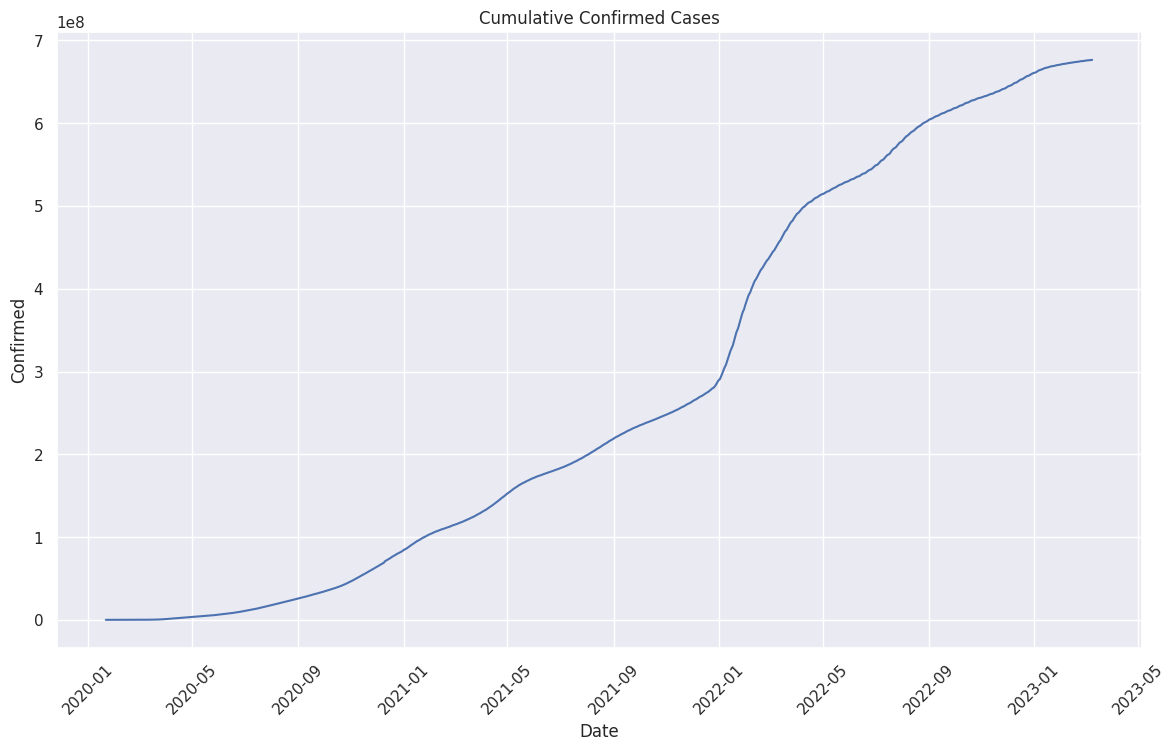

In [8]:
sns.set(style="darkgrid")
plt.figure(figsize=(14,8))

# Cumulative confirmed cases
sns.lineplot(data=global_daily, x='Date', y='Confirmed')
plt.title('Cumulative Confirmed Cases')
plt.xticks(rotation=45)
plt.show()

In [9]:
latest = covid_19_data[covid_19_data['Date'] == covid_19_data['Date'].max()]

In [10]:
top10_cases = latest.sort_values('Confirmed', ascending=False).head(10)
top10_deaths = latest.sort_values('Deaths', ascending=False).head(10)
top10_recovered = latest.sort_values('Recovered', ascending=False).head(10)

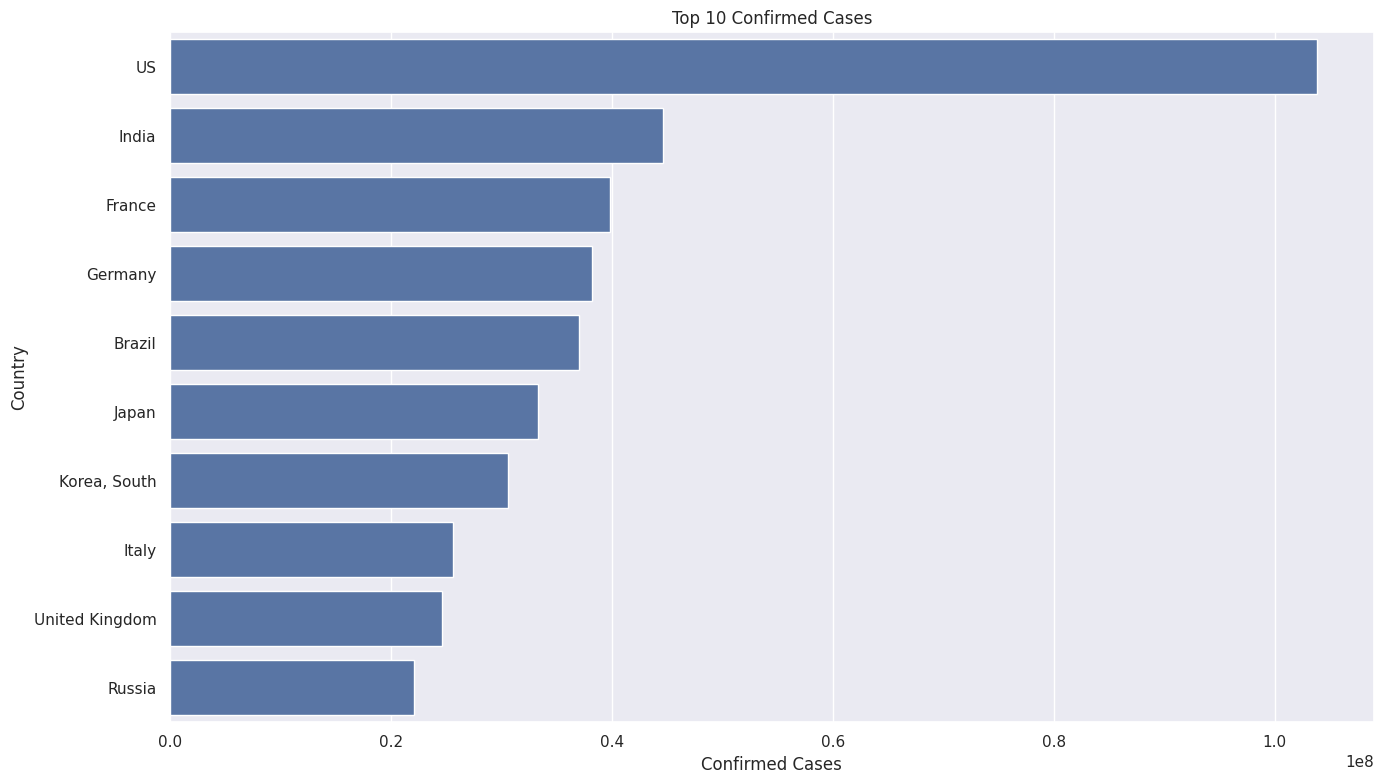

In [11]:
sns.set_style("darkgrid")

plt.figure(figsize=(14, 8))

# Top 10 confirmed
sns.barplot(data=top10_cases, y='Country', x='Confirmed')
plt.title('Top 10 Confirmed Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

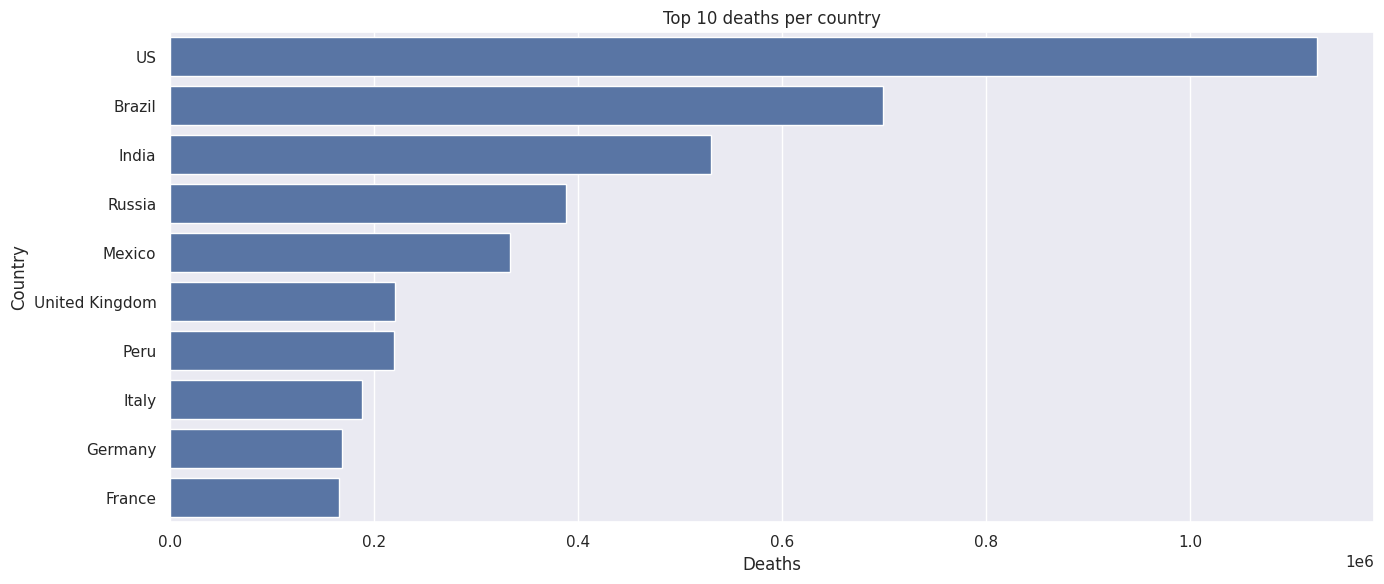

In [12]:
sns.set_style("darkgrid")

plt.figure(figsize=(14,6))
sns.barplot(data = top10_deaths,y= 'Country',x= 'Deaths')
plt.title('Top 10 deaths per country')
plt.xlabel('Deaths')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

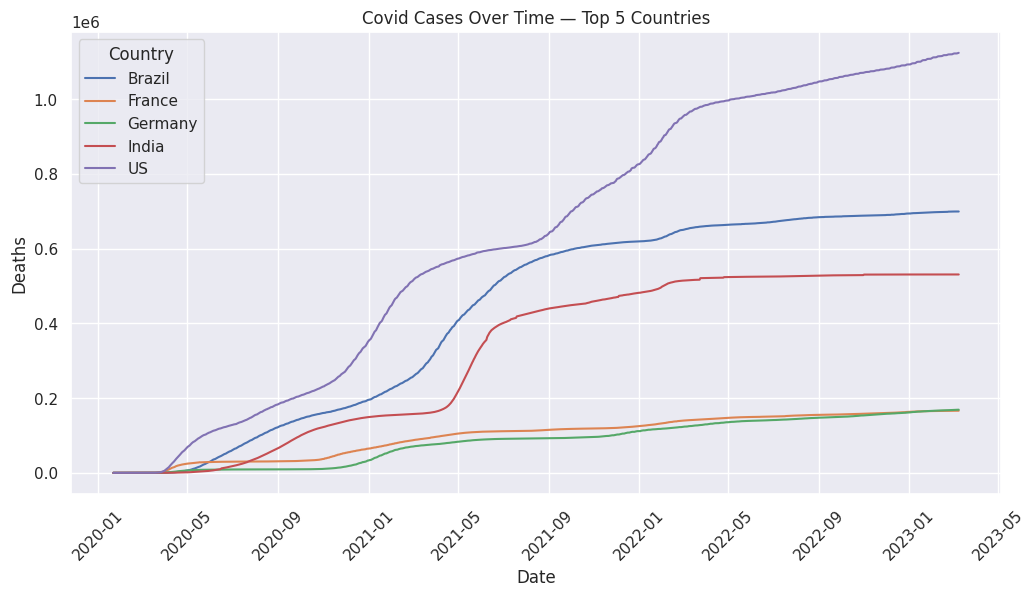

In [14]:
top_5_cases = top10_cases.head(5)['Country']
filtered = covid_19_data[covid_19_data['Country'].isin(top_5_cases)]

plt.figure(figsize=(12,6))
sns.lineplot(data=filtered, x='Date', y='Deaths', hue='Country')

plt.title('Covid Cases Over Time — Top 5 Countries')
plt.xticks(rotation=45)
plt.show()

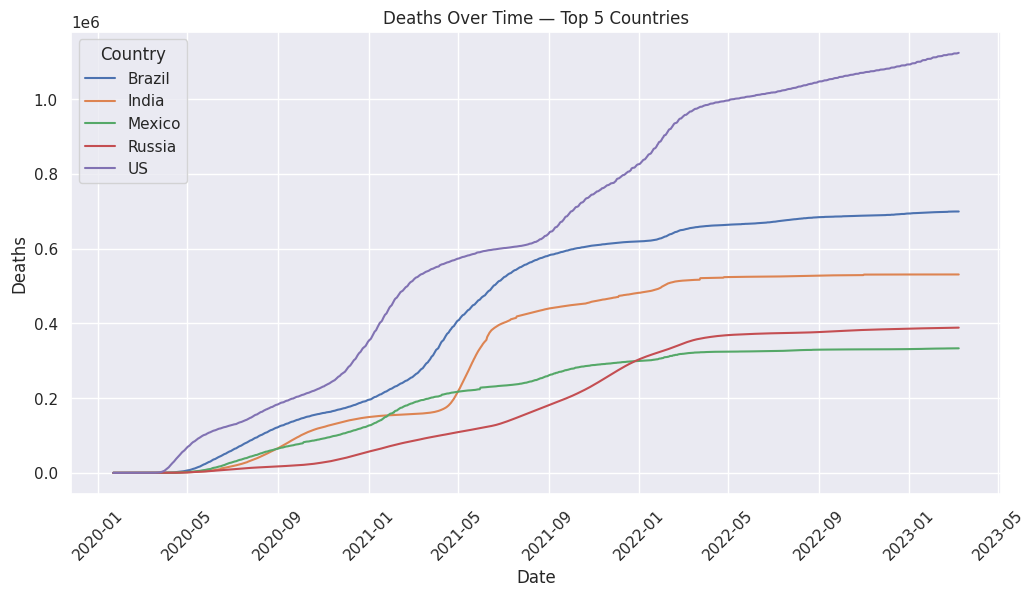

In [15]:
top_5_deaths = top10_deaths.head(5)['Country']
filtered = covid_19_data[covid_19_data['Country'].isin(top_5_deaths)]

plt.figure(figsize=(12,6))
sns.lineplot(data=filtered, x='Date', y='Deaths', hue='Country')

plt.title('Deaths Over Time — Top 5 Countries')
plt.xticks(rotation=45)
plt.show()

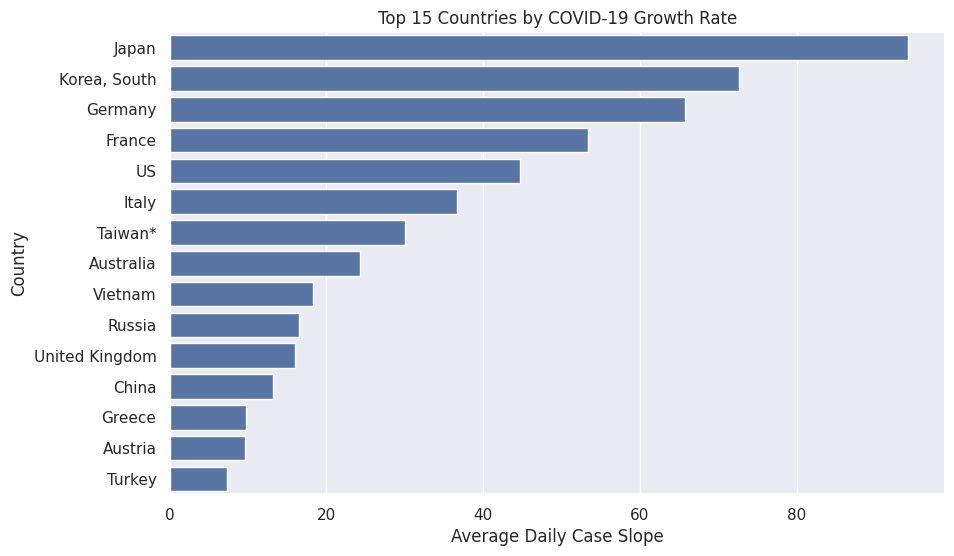

In [16]:
#Calculate the slope of cases per time region
def calc_slope(series):
    x = np.arange(len(series))
    if len(x) < 2:
        return 0
    return round(np.polyfit(x, series.values, 1)[0], 2)

slopes = (
    covid_19_data.groupby('Country')['New_Confirmed']
      .apply(calc_slope)
      .reset_index(name='Avg_Daily_Slope')
      .sort_values(by='Avg_Daily_Slope', ascending=False)
)

sns.set_style("darkgrid")

top15 = slopes.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top15, y='Country', x='Avg_Daily_Slope')

plt.title('Top 15 Countries by COVID-19 Growth Rate')
plt.xlabel('Average Daily Case Slope')
plt.show()

In [17]:
print(type(top10_cases))
print(top10_cases)


<class 'pandas.core.frame.DataFrame'>
               Country       Date  Confirmed   Deaths  Recovered  \
229728              US 2023-03-09  103802702  1123836          0   
229622           India 2023-03-09   44690738   530779          0   
229605          France 2023-03-09   39866718   166176          0   
229609         Germany 2023-03-09   38249060   168935          0   
229566          Brazil 2023-03-09   37076053   699276          0   
229630           Japan 2023-03-09   33320438    72997          0   
229636    Korea, South 2023-03-09   30615522    34093          0   
229628           Italy 2023-03-09   25603510   188322          0   
229732  United Kingdom 2023-03-09   24658705   220721          0   
229689          Russia 2023-03-09   22075858   388478          0   

        New_Confirmed  New_Deaths  
229728        46931.0       590.0  
229622          440.0         3.0  
229605         6308.0        11.0  
229609         7829.0       127.0  
229566            0.0         0.0

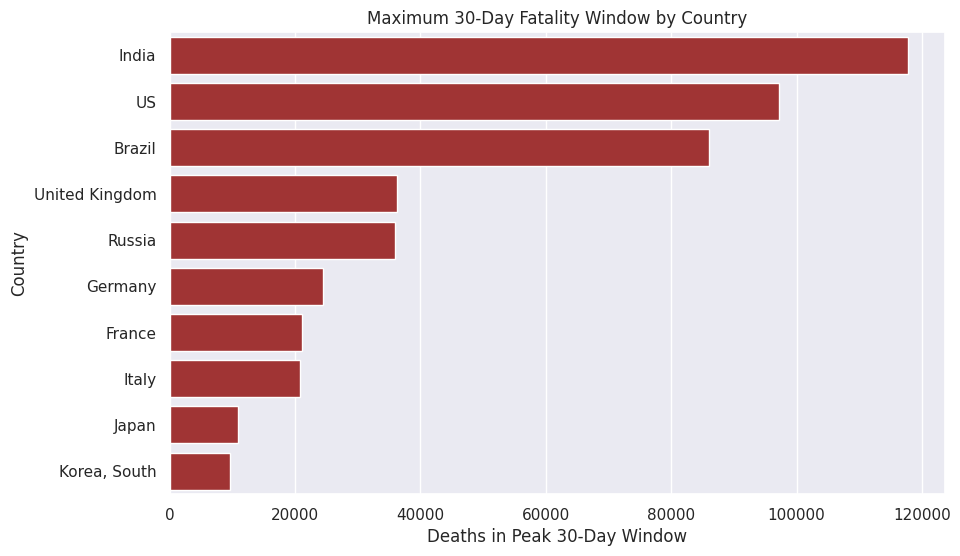

In [18]:
# Find the 30-day window with the maximum death increase per country (top 10)
window_size = 30
results = []
top10_cases = covid_19_data.groupby('Country')['Confirmed'].max().nlargest(10).index.tolist()

for country in top10_cases:
    sub = covid_19_data[covid_19_data['Country'] == country].sort_values('Date')
    rolling = sub['New_Deaths'].rolling(window_size).sum()
    if rolling.dropna().empty:
        continue

    peak_idx = rolling.idxmax()

    results.append({
        'Country': country,
        'Peak_Window_End': sub.loc[peak_idx, 'Date'],
        'Total_Deaths_In_Window': rolling.max()
    })

window_df = (
    pd.DataFrame(results)
    .sort_values('Total_Deaths_In_Window', ascending=False)
)

sns.set_style("darkgrid")

plt.figure(figsize=(10,6))

sns.barplot(
    data=window_df,
    y='Country',
    x='Total_Deaths_In_Window',
    color='firebrick'
)

plt.title('Maximum 30-Day Fatality Window by Country')
plt.xlabel('Deaths in Peak 30-Day Window')

plt.show()

COVID-19 Data Visualisation

Overview

This section handles the bulk of the project's visual analysis, progressively building from global trends down to granular country-level insights using seaborn and matplotlib.

Global Trend Analysis
The code begins by aggregating the dataset by date using groupby(), summing all key metrics into a global_daily DataFrame. This is used to render a line chart of cumulative confirmed cases over time, providing a high-level view of the pandemic's overall trajectory across the entire dataset's time range.

Top 10 Country Comparisons
The dataset is filtered to the most recent date to capture the latest snapshot, from which the top 10 countries by confirmed cases, deaths, and recoveries are extracted using sort_values() and head(10). These rankings are visualised as horizontal bar charts, making cross-country comparisons clean and immediate.

Country Progression Over Time
The analysis narrows to the top 5 countries by confirmed cases and deaths respectively, plotting their progression as time series line charts with hue='Country' to distinguish between nations — revealing how differently the pandemic evolved across regions.

Growth Rate Analysis
A custom calc_slope() function computes the average daily growth rate of new confirmed cases per country using np.polyfit(), which fits a linear trend line to the data. The top 15 countries by this slope are then visualised in a bar chart, effectively identifying which nations experienced the steepest accelerations in case growth.

Peak 30-Day Fatality Window
A rolling 30-day window analysis is performed across the top 10 countries by total confirmed cases, summing new deaths within each window to isolate each country's single deadliest 30-day period. Results are plotted as a bar chart in firebrick red, offering a stark comparison of peak fatality burdens across the worst-affected nations.

#Step 4: Rolling mean and standard deviation

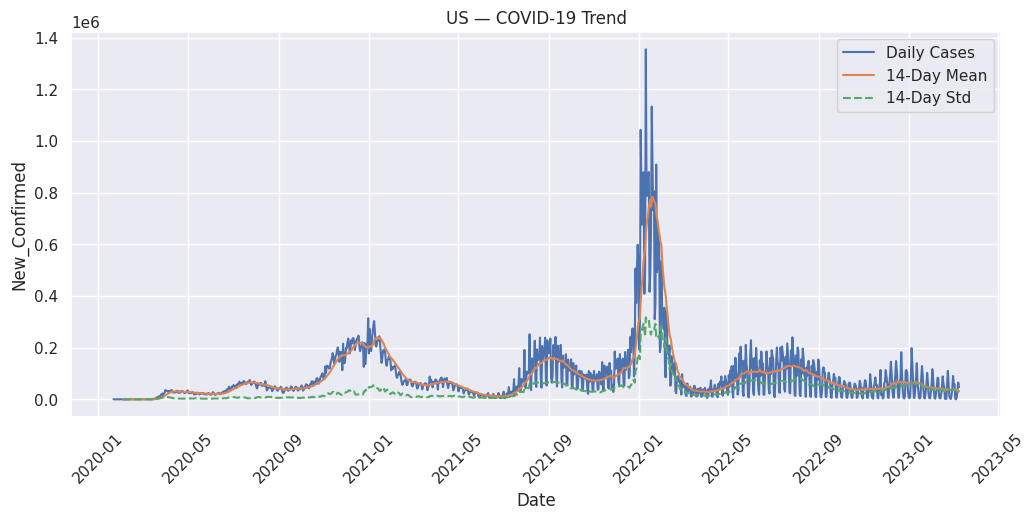

In [20]:
sns.set_style("darkgrid")

COUNTRY = 'US'

ts_data = (
    covid_19_data[covid_19_data['Country'] == COUNTRY]
    .sort_values('Date')
    .set_index('Date')['New_Confirmed']
    .clip(lower=0)
    .fillna(0)
)

rolling_mean = ts_data.rolling(14).mean()
rolling_std  = ts_data.rolling(14).std()

plt.figure(figsize=(12,5))

sns.lineplot(data=ts_data, label='Daily Cases')
sns.lineplot(data=rolling_mean, label='14-Day Mean')
sns.lineplot(data=rolling_std, label='14-Day Std', linestyle='--')

plt.title(f'{COUNTRY} — COVID-19 Trend')
plt.xticks(rotation=45)

plt.show()

Overview

This step performs a smoothed trend analysis on daily new confirmed COVID-19 cases for a specific country — in this case, the United States ('US'). By computing a 14-day rolling mean and standard deviation, the analysis cuts through the noise of day-to-day fluctuations to reveal the broader trajectory of the pandemic.

Data Preparation
The dataset is filtered to the selected country and sorted chronologically by date, with the Date column set as the index. The New_Confirmed series is then cleaned using .clip(lower=0) to eliminate any negative values that may have resulted from data corrections, and .fillna(0) to handle any missing entries — ensuring the time series is continuous and stable before any calculations are applied.

Rolling Statistics
A 14-day rolling window is applied to compute two statistics — the mean and the standard deviation. The rolling mean smooths short-term volatility, making underlying wave patterns more visible, while the rolling standard deviation measures the variability or spread of daily cases within each 14-day window, serving as an indicator of how erratic or stable the case counts were during any given period.

Visualisation
All three series — raw daily cases, the 14-day mean, and the 14-day standard deviation — are plotted on a single chart. The standard deviation is rendered as a dashed line to visually distinguish it from the trend lines. The chart title is dynamically generated using an f-string, making it straightforward to swap the COUNTRY variable and rerun the analysis for any nation in the dataset.

#Step 5: The Dickey fuller test

In [22]:
def adf_test(series, name):
    result = adfuller(series.dropna())

    print(f"\nADF Test — {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    if result[1] < 0.05:
        print("Stationary — reject the null hypothesis (p < 0.05)")
    else:
        print("Not Stationary — fail to reject the null hypothesis (p >= 0.05)")

# Test raw series
adf_test(ts_data, name=f'{COUNTRY} Daily New Cases (Raw)')

# Difference the series to make it stationary
ts_diff = ts_data.diff().dropna()
adf_test(ts_diff, name=f'{COUNTRY} Daily New Cases (1st Difference)')


ADF Test — US Daily New Cases (Raw)
ADF Statistic: -4.3225
p-value: 0.0004
Stationary — reject the null hypothesis (p < 0.05)

ADF Test — US Daily New Cases (1st Difference)
ADF Statistic: -7.5212
p-value: 0.0000
Stationary — reject the null hypothesis (p < 0.05)


Overview

This step formally tests whether the COVID-19 daily case time series is stationary — a critical prerequisite for many time series forecasting models such as ARIMA. The Augmented Dickey-Fuller (ADF) test is a standard statistical test used to determine whether a unit root is present in the series, which would indicate non-stationarity.

The adf_test() Function
A reusable function is defined to wrap the adfuller() method from statsmodels. It accepts a time series and a label name, drops any null values before testing, and prints three key outputs — the ADF statistic, the p-value, and a plain-English interpretation of the result. If the p-value falls below the 0.05 significance threshold, the null hypothesis of a unit root is rejected, confirming the series is stationary. Otherwise, the series is deemed non-stationary and requires further transformation.

Testing the Raw Series
The ADF test is first applied to the raw ts_data series of daily new confirmed cases. Given the visible waves and trends observed in the previous visualisation, this series is likely to return a non-stationary result, meaning its statistical properties — such as mean and variance — shift over time.

First Differencing
To address non-stationarity, the series is differenced once using .diff().dropna(), which computes the day-on-day change in new confirmed cases rather than the raw counts. The ADF test is then reapplied to this transformed series. First differencing is a standard remediation technique that removes trends and stabilises the mean, typically yielding a stationary series ready for use in forecasting models.


Note: Stationarity is not merely a technical formality — forecasting models trained on non-stationary data tend to produce unreliable and misleading predictions, making this step an essential part of rigorous time series analysis.

#Step 6: ARIMA order selection

<Figure size 1000x400 with 0 Axes>

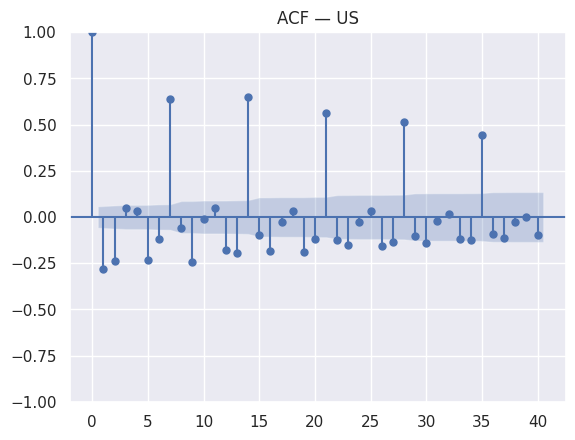

In [23]:
# ACF
plt.figure(figsize=(10,4))
plot_acf(ts_diff.dropna(), lags=40)
plt.title(f'ACF — {COUNTRY}')
plt.show()

<Figure size 1000x400 with 0 Axes>

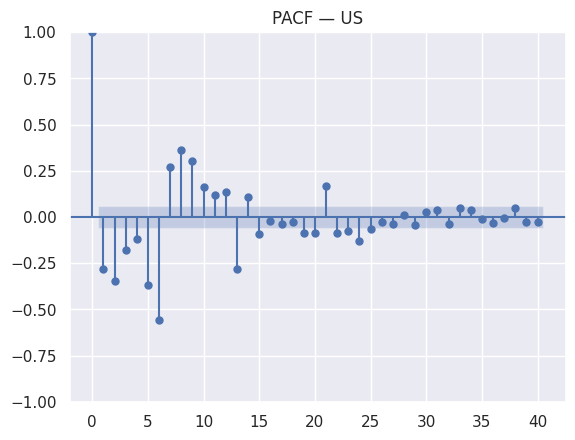

In [24]:
# PACF
plt.figure(figsize=(10,4))
plot_pacf(ts_diff.dropna(), lags=40)
plt.title(f'PACF — {COUNTRY}')
plt.show()

Overview

This step uses two diagnostic plots — the Autocorrelation Function (ACF) and the Partial Autocorrelation Function (PACF) — to inform the selection of the appropriate order parameters for the ARIMA model. Rather than guessing the model configuration, these plots provide a principled, visual basis for choosing the p, d, and q values that define an ARIMA model's structure.

Autocorrelation Function (ACF)
The ACF plot measures the correlation between the time series and its own lagged values across up to 40 lags. It reveals how strongly past observations influence future ones, and over how many time steps that influence persists. In the context of ARIMA, the ACF is primarily used to determine the moving average order q — the point at which the autocorrelation drops off or "cuts off" indicates a suitable value for q. The differenced series ts_diff is used here to ensure the plot reflects stationary data.

Partial Autocorrelation Function (PACF)
The PACF plot similarly measures correlation between the series and its lags, but crucially controls for the influence of all intermediate lags — isolating the direct relationship between an observation and a specific lag. This makes it the appropriate tool for identifying the autoregressive order p — the lag at which the partial autocorrelation sharply cuts off suggests the optimal value for p.

Interpreting the Plots
Together, the ACF and PACF plots form a complementary pair. A sharp cutoff in the PACF alongside a gradual decay in the ACF suggests an AR process, whilst the reverse pattern points to an MA process. A combination of both patterns indicates a mixed ARIMA model is appropriate.


Note: Both plots are generated on the differenced series ts_diff.dropna() rather than the raw data, as ACF and PACF diagnostics are only meaningful when applied to a stationary series — as confirmed by the ADF test in the previous step.

#Step 7: Train Test Split

Train: 904 | Test: 226


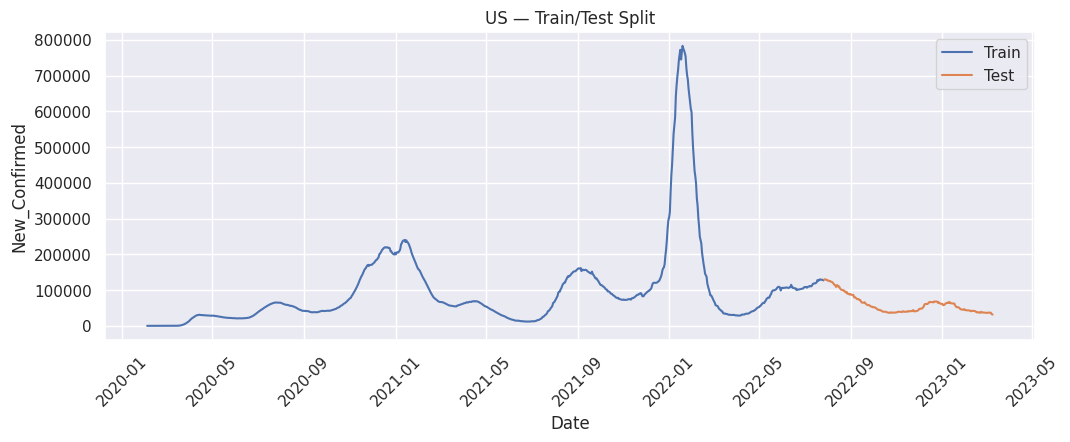

In [25]:
sns.set_style("darkgrid")

ts_smooth = ts_data.rolling(14).mean().dropna()  # 14-day

# Split
split_idx = int(len(ts_smooth) * 0.8)
train = ts_smooth[:split_idx]
test  = ts_smooth[split_idx:]

print(f"Train: {len(train)} | Test: {len(test)}")

# Plot
plt.figure(figsize=(12,4))
sns.lineplot(data=train, label='Train')
sns.lineplot(data=test, label='Test')

plt.title(f'{COUNTRY} — Train/Test Split')
plt.xticks(rotation=45)

plt.show()

Overview

This step prepares the time series data for model training and evaluation by dividing it into a training set and a test set. Crucially, the split is performed on a smoothed version of the series rather than the raw daily figures, reducing the influence of short-term noise and producing a more stable signal for the ARIMA model to learn from.

Smoothing the Series
Before splitting, a 14-day rolling mean is applied to ts_data and any resulting null values from the rolling window are dropped using .dropna(). This smoothed series, ts_smooth, carries forward the same smoothing approach used in the earlier trend analysis, ensuring consistency across the pipeline and presenting the model with a cleaner, more representative signal.

Splitting the Data
The smoothed series is split at the 80th percentile of its length using an integer index derived from int(len(ts_smooth) * 0.8). The first 80% of observations form the training set, on which the ARIMA model will be fitted, whilst the remaining 20% constitute the test set, held back exclusively for evaluating how well the model generalises to unseen data. The sizes of both sets are printed as a quick sanity check before proceeding.

Visualisation
Both the training and test sets are plotted on a single line chart using distinct labels, providing a clear visual confirmation of where the split occurs in the timeline. This is an important step in ensuring the chronological integrity of the split — unlike with cross-sectional data, time series data must always be split sequentially to prevent data leakage from future observations into the training period.


Note: The 80/20 split is a widely adopted convention in time series modelling, though the optimal ratio may vary depending on the length of the series and the forecasting horizon required.


In [26]:
# ARIMA(p,d,q) — based on ACF/PACF analysis above
# Adjust (p,d,q) as needed after inspecting the ACF/PACF plots
p, d, q = 2, 1, 2

print(f"Fitting ARIMA({p},{d},{q}) on {COUNTRY} training data...")
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())

Fitting ARIMA(2,1,2) on US training data...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          New_Confirmed   No. Observations:                  904
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -8781.350
Date:                Wed, 25 Mar 2026   AIC                          17572.699
Time:                        21:43:34   BIC                          17596.728
Sample:                    02-04-2020   HQIC                         17581.877
                         - 07-26-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3263      0.096      3.384      0.001       0.137       0.515
ar.L2          0.6176      0.092      6.704      0.000       0.437       0.798
ma.L1          0.0972      0.091      1.064      0.2

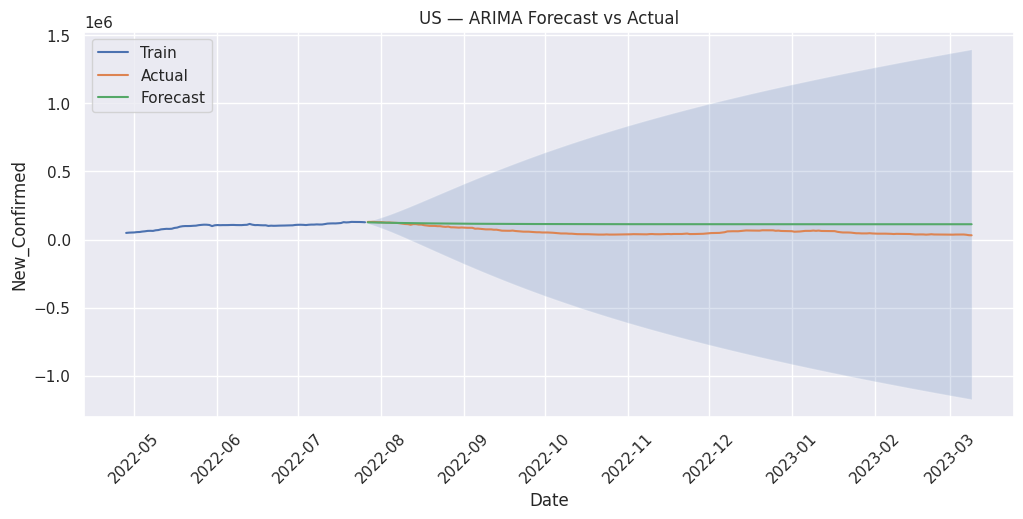

In [27]:
sns.set_style("darkgrid")

# Forecast
n_forecast = len(test)
forecast = model_fit.get_forecast(steps=n_forecast)

forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Align index
forecast_mean.index = test.index
conf_int.index = test.index

# Plot
plt.figure(figsize=(12,5))

sns.lineplot(data=train[-90:], label='Train')
sns.lineplot(data=test, label='Actual')
sns.lineplot(data=forecast_mean, label='Forecast')

plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2
)

plt.title(f'{COUNTRY} — ARIMA Forecast vs Actual')
plt.xticks(rotation=45)

plt.show()

In [28]:
# Convert to arrays
actual = np.array(test)
pred = np.array(forecast_mean)

# Avoid division by zero for MAPE
mask = actual != 0

mape_val = np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100
rmse_val = np.sqrt(np.mean((actual - pred) ** 2))

print(f"\nModel Evaluation — ARIMA({p},{d},{q}) on {COUNTRY}")
print(f"MAPE: {mape_val:.2f}%")
print(f"RMSE: {rmse_val:,.0f}")

print("\nConfidence Interval (avg):")
print(f"Lower: {conf_int.iloc[:,0].mean():,.0f}")
print(f"Upper: {conf_int.iloc[:,1].mean():,.0f}")


Model Evaluation — ARIMA(2,1,2) on US
MAPE: 117.20%
RMSE: 58,773

Confidence Interval (avg):
Lower: -635,326
Upper: 864,095


Overview

This step brings together all prior preparation — smoothing, stationarity testing, and order selection — into the fitting and evaluation of the ARIMA model. It covers three distinct phases: model training, forecasting, and performance measurement.

Model Fitting
The ARIMA model is instantiated with the orders (p=2, d=1, q=2), derived from the ACF and PACF diagnostics carried out in Step 6. These parameters define the autoregressive, differencing, and moving average components of the model respectively. The model is fitted on the training set using .fit(), and a full statistical summary is printed via model_fit.summary(), which reports coefficient estimates, standard errors, and goodness-of-fit metrics useful for validating the model's structure.

Forecasting
The fitted model generates forecasts for a number of steps equal to the length of the test set using get_forecast(). Both the predicted mean and the confidence intervals are extracted and their indices realigned to match the test set's date index, ensuring the forecast maps correctly onto the actual timeline. The visualisation plots the final 90 days of the training set alongside the actual test values and the forecast, with a shaded band representing the confidence interval — providing an intuitive picture of both the forecast direction and its associated uncertainty.

Model Evaluation
Two standard error metrics are computed to quantify forecast accuracy. The RMSE (Root Mean Squared Error) measures the average magnitude of forecast errors in the same units as the original series, penalising larger deviations more heavily. The MAPE (Mean Absolute Percentage Error) expresses the average error as a percentage of actual values, offering a scale-independent measure of accuracy that is straightforward to interpret. A mask is applied before computing MAPE to exclude any zero values in the actual series, preventing division errors. The average lower and upper bounds of the confidence interval are also printed, giving a sense of the forecast's range of uncertainty.


Note: The (p=2, d=1, q=2) order is a reasonable starting point informed by the ACF and PACF plots, but should be revisited and tuned if the MAPE or RMSE values suggest the model is underperforming. Tools such as auto_arima from the pmdarima library can automate this selection process for more rigorous optimisation.


#Step 8: Key Insights

In [31]:
# Generate key insights
latest_global = global_daily.iloc[-1]
peak_day = global_daily.loc[global_daily['New_Confirmed'].idxmax()]
top_country_cases  = latest.iloc[0]
top_country_deaths = latest.sort_values('Deaths', ascending=False).iloc[0]
highest_slope = slopes.iloc[0]


print(f"\n1. GLOBAL TOTALS (as of {covid_19_data['Date'].max().date()}):")
print(f"   Confirmed : {latest_global['Confirmed']/1e6:.1f}M")
print(f"   Deaths    : {latest_global['Deaths']/1e6:.2f}M")
print(f"   Recovered : {latest_global['Recovered']/1e6:.1f}M")

print(f"\n2. PEAK SINGLE DAY (global):")
print(f"   Date      : {peak_day['Date'].date()}")
print(f"   New Cases : {int(peak_day['New_Confirmed']):,}")

print(f"\n3. HIGHEST BURDEN COUNTRIES:")
print(f"   Most Cases  : {top_country_cases['Country']} ({top_country_cases['Confirmed']/1e6:.1f}M)")
print(f"   Most Deaths : {top_country_deaths['Country']} ({top_country_deaths['Deaths']/1e6:.2f}M)")

print(f"\n4. FASTEST GROWING REGION (slope analysis):")
print(f"   Country   : {highest_slope['Country']}")
print(f"   Avg Slope : {highest_slope['Avg_Daily_Slope']:,.0f} new cases/day (trend)")

print(f"\n5. ARIMA MODEL PERFORMANCE ({COUNTRY}):")
print(f"   MAPE : {mape_val:.2f}%")
print(f"   RMSE : {rmse_val:,.0f} cases")
print("\n" + "="*60)


1. GLOBAL TOTALS (as of 2023-03-09):
   Confirmed : 676.6M
   Deaths    : 6.88M
   Recovered : 0.0M

2. PEAK SINGLE DAY (global):
   Date      : 2022-01-19
   New Cases : 4,083,281

3. HIGHEST BURDEN COUNTRIES:
   Most Cases  : Afghanistan (0.2M)
   Most Deaths : US (1.12M)

4. FASTEST GROWING REGION (slope analysis):
   Country   : Japan
   Avg Slope : 94 new cases/day (trend)

5. ARIMA MODEL PERFORMANCE (US):
   MAPE : 117.20%
   RMSE : 58,773 cases



Overview

This final step consolidates the entire analysis into a concise, structured summary of the most significant findings drawn from the dataset. Rather than introducing any new transformations or models, it serves as a reporting layer — extracting and presenting the most meaningful statistics in a readable, human-friendly format.

Global Totals
The most recent row of the global_daily DataFrame is retrieved to report the cumulative worldwide figures for confirmed cases, deaths, and recoveries as of the latest date in the dataset. Values are scaled to millions for readability, giving an immediate sense of the pandemic's overall magnitude at its conclusion point in the data.

Peak Single Day
The global daily DataFrame is scanned using idxmax() on the New_Confirmed column to identify the single day on which the highest number of new cases was recorded worldwide. Both the date and the case count are reported, pinpointing the most intense moment of the pandemic's spread in the dataset.

Highest Burden Countries
The latest snapshot of the dataset is used to surface the two countries that bore the heaviest burden — one ranked by total confirmed cases and the other by total deaths. These are not necessarily the same country, and reporting them separately acknowledges that case fatality rates varied considerably across nations due to differences in healthcare capacity, reporting standards, and population demographics.

Fastest Growing Region
Drawing on the slope analysis conducted during the visualisation phase, the country with the highest average daily case growth rate is highlighted. This metric goes beyond raw totals to identify which nation experienced the most rapid acceleration in new cases, offering a dynamic perspective on outbreak severity rather than a purely cumulative one.

ARIMA Model Performance
The final insight reports the forecasting model's accuracy metrics — MAPE and RMSE — for the selected country, serving as a quantitative verdict on how reliably the ARIMA model captured the pandemic's trajectory. Together, these figures contextualise the forecasts produced in the previous step and indicate how much confidence can be placed in the model's predictions.


Note: This summary block is designed to be modular and reusable — swapping the COUNTRY variable or updating the dataset will automatically refresh all printed insights without any changes to the code structure itself.
